# Ensemble Learning: Ансамбли моделей

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings


## 1. Загрузка и подготовка данных

In [2]:
# Загрузка датасета Bank Marketing
df = pd.read_csv('datasets/bank_marketing_train.csv', sep=';')

# Целевая переменная: yes/no -> 1/0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Преобразование категориальных признаков
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Признаки и целевая переменная
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Сохраняем названия признаков
feature_names = X.columns.tolist()

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер датасета: {df.shape}")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов:")
print(f"  - Не подписался (0): {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  - Подписался (1): {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.1f}%)")

Размер датасета: (45211, 17)
Обучающая выборка: (36168, 42)
Тестовая выборка: (9043, 42)

Распределение классов:
  - Не подписался (0): 39922 (88.3%)
  - Подписался (1): 5289 (11.7%)


## 2. Базовая модель: Decision Tree

In [3]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")

Decision Tree Accuracy: 0.8776


## 3. Random Forest (Bagging)

**Random Forest** = Bagging + деревья решений + случайный выбор признаков

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Улучшение по сравнению с Decision Tree: {(acc_rf - acc_dt):.4f}")

Random Forest Accuracy: 0.9049
Улучшение по сравнению с Decision Tree: 0.0273


## 4. XGBoost (Boosting)

In [5]:
# Установка: pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")

XGBoost Accuracy: 0.9047


### 4.1 Feature Importance в XGBoost

**Feature Importance** показывает, какие признаки наиболее важны для предсказаний модели.

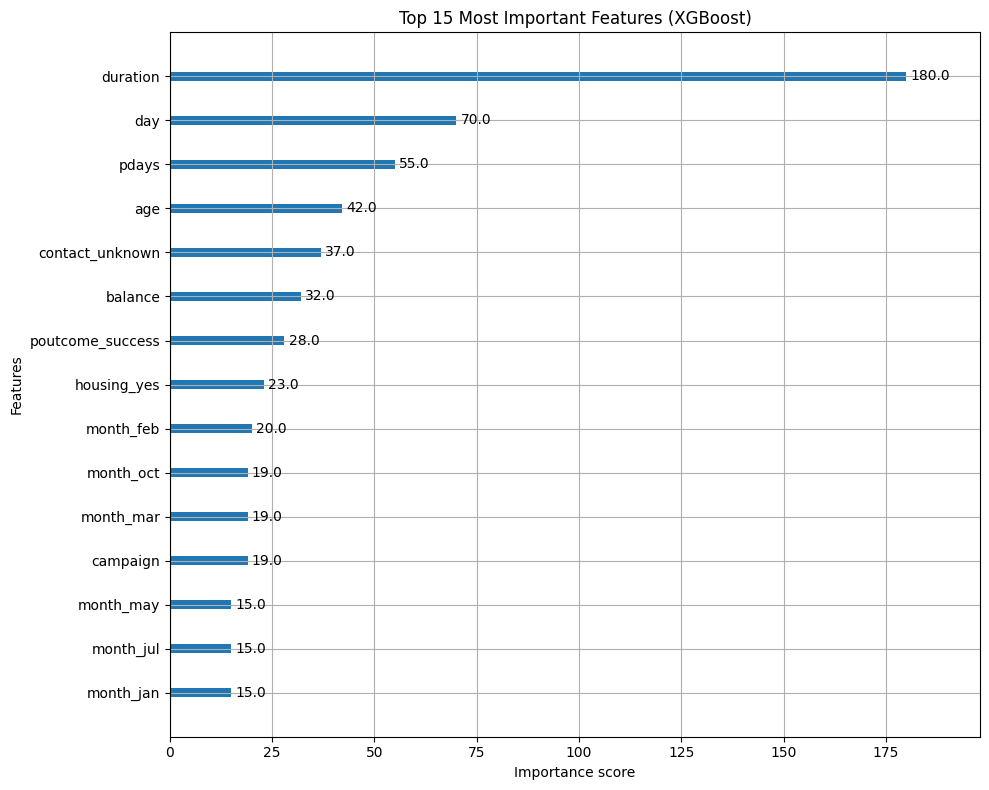

In [6]:
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb, ax=ax, max_num_features=15)
plt.title('Top 15 Most Important Features (XGBoost)')
plt.tight_layout()
plt.show()

In [7]:
# Таблица с важностью признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


Top 10 Most Important Features:
             feature  importance
40  poutcome_success    0.213614
3           duration    0.113010
24       housing_yes    0.075039
27   contact_unknown    0.070526
34         month_mar    0.054568
33         month_jun    0.050194
37         month_oct    0.038978
14       job_student    0.036330
0                age    0.029572
38         month_sep    0.027075


## 5. Classification Report и Confusion Matrix

In [8]:
# Classification Report для Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Не подписался', 'Подписался']))

Random Forest Classification Report:
               precision    recall  f1-score   support

Не подписался       0.92      0.97      0.95      7985
   Подписался       0.66      0.39      0.49      1058

     accuracy                           0.90      9043
    macro avg       0.79      0.68      0.72      9043
 weighted avg       0.89      0.90      0.89      9043



### Задание
Попробуйте другой набор данных с разными параметрами